# Fresh Orange vs Formalin-mixed Orange - Colab

## Setup and Kaggle API Configuration

In [ ]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from google.colab import userdata
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Kaggle Credentials from Colab Secrets
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("Kaggle credentials loaded.")
except Exception as e:
    print("Kaggle credentials not found in Secrets. If files exist, skipping is fine.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


In [ ]:
results_dir = "/content/results/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs("/content/models", exist_ok=True)


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
print(gpus if gpus else 'No GPU - Runtime > Change runtime type > GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download dataset

In [ ]:
DATASET_NAME = "sumitkumerdas/fresh-rotten-and-formalin-mixed-fruit-detection"
DATASET_ROOT_DIR = "/content/fruitvision_data"
# The path inside the Kaggle dataset structure
DATASET_DIR = os.path.join(DATASET_ROOT_DIR, 'FruitVision A Benchmark Dataset for Fresh, Rotten, and Formalin-mixed Fruit Detection')

if not os.path.exists(DATASET_DIR):
    if os.path.exists(DATASET_ROOT_DIR):
        shutil.rmtree(DATASET_ROOT_DIR)
    os.makedirs(DATASET_ROOT_DIR, exist_ok=True)

    print("Downloading dataset from Kaggle...")
    !kaggle datasets download -d {DATASET_NAME} -p {DATASET_ROOT_DIR} --unzip

    # The Kaggle unzip usually creates the same nested structure
    if os.path.exists(DATASET_DIR):
        cwd = os.getcwd()
        os.chdir(DATASET_DIR)
        for z in ['Augmented-Resized Image.zip', 'Original Image.zip']:
            if os.path.exists(z):
                print(f"Extracting nested zip: {z}...")
                !unzip -o -q "{z}"
                os.remove(z)
        os.chdir(cwd)
        print("Extraction complete!")
else:
    print("Dataset already exists on disk. Skipping download.")

Dataset already exists on disk. Skipping download.


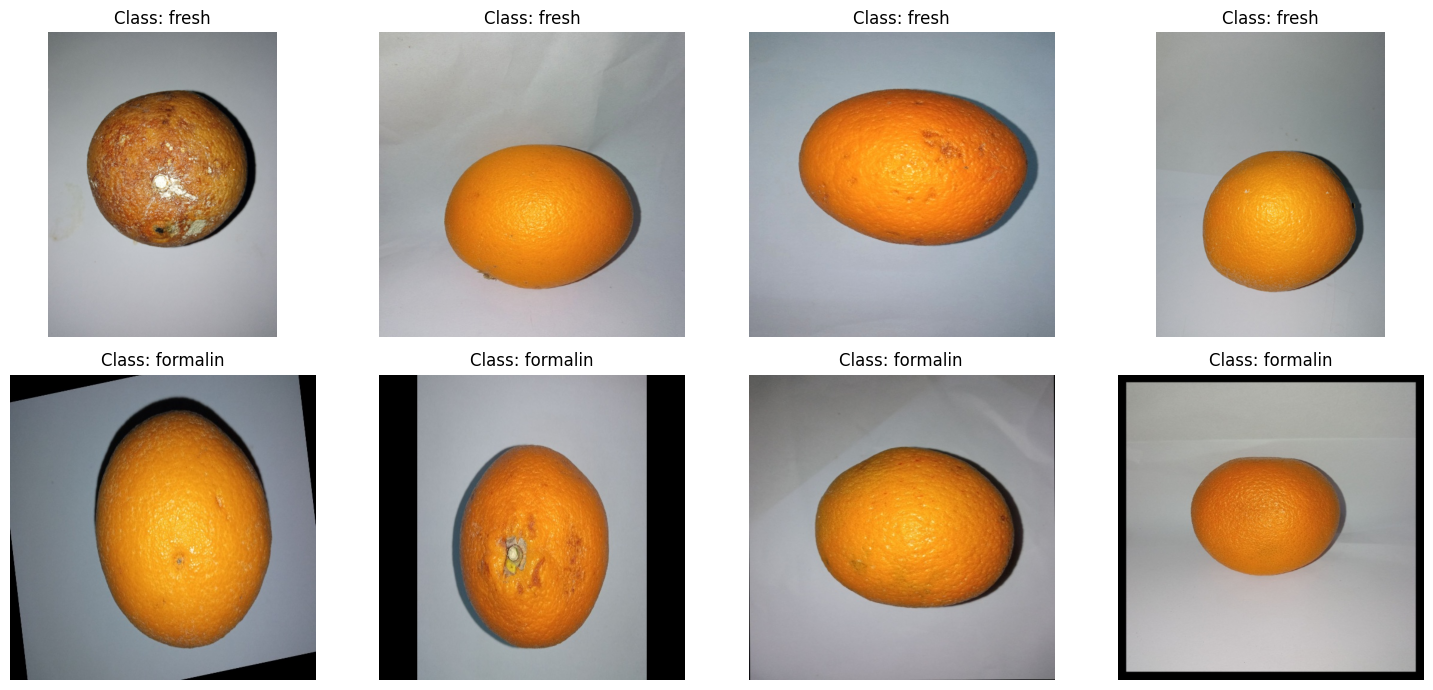

In [ ]:
def visualize_curated_data(all_files, num_images=4):
    plt.figure(figsize=(15, 7))
    # Ensure we only iterate over the keys we expect for CV06
    classes_to_show = ['fresh', 'formalin']
    for i, class_name in enumerate(classes_to_show):
        file_list = all_files.get(class_name, [])
        if not file_list:
            print(f"No images found for class: {class_name}")
            continue

        samples = random.sample(file_list, min(num_images, len(file_list)))
        for j, img_path in enumerate(samples):
            plt.subplot(len(classes_to_show), num_images, i * num_images + j + 1)
            img = mpimg.imread(str(img_path))
            plt.imshow(img)
            plt.title(f"Class: {class_name}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

if 'all_files' in globals() and any(len(v) > 0 for v in all_files.values()):
    visualize_curated_data(all_files)
else:
    print("No files found to display. Please ensure cell b033d00e has been run.")

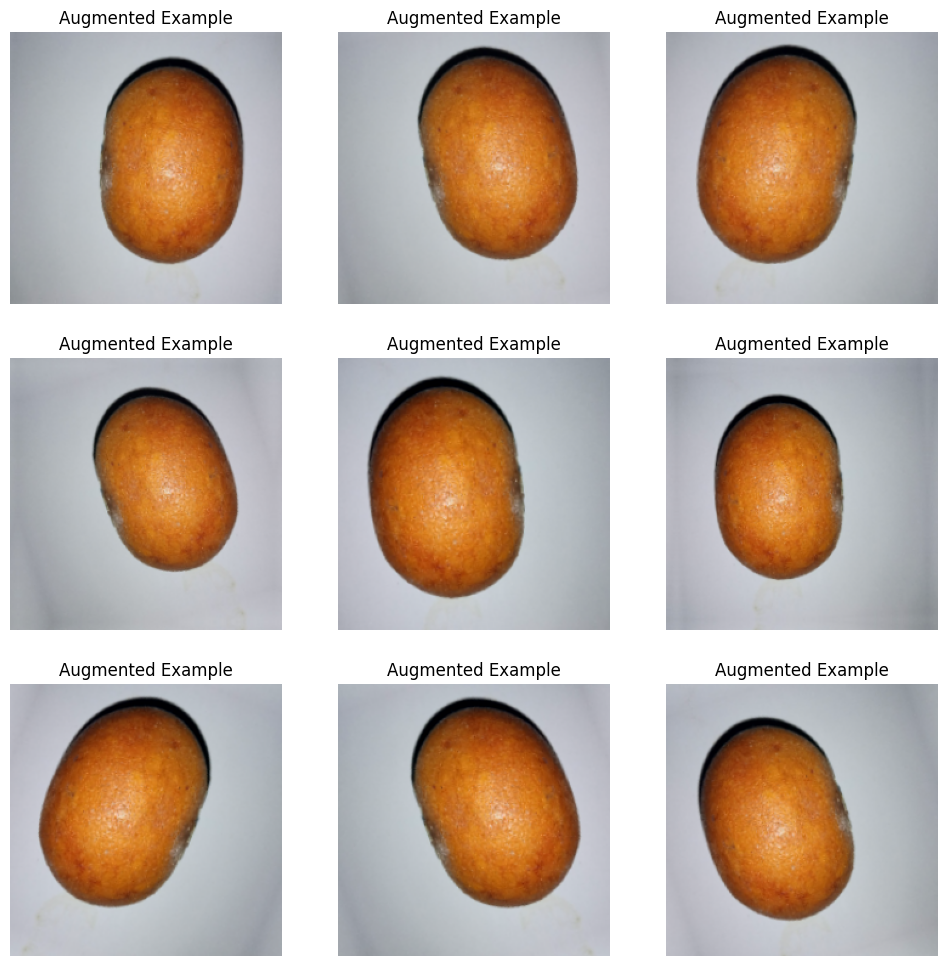

In [ ]:
def show_augmentation_results(dataset, augmentation_layer):
    plt.figure(figsize=(12, 12))
    # Take one batch from the dataset
    for images, _ in dataset.take(1):
        # Show the first image in the batch in various augmented states
        for i in range(9):
            # Data augmentation layers expect batch dimension and float input
            augmented_images = augmentation_layer(images, training=True)
            plt.subplot(3, 3, i + 1)
            # Convert back to uint8 for display
            plt.imshow(augmented_images[0].numpy().astype("uint8"))
            plt.title("Augmented Example")
            plt.axis("off")
    plt.show()

try:
    # Pass the raw train_dataset before caching/shuffling for clean visualization
    show_augmentation_results(train_dataset, data_augmentation)
except Exception as e:
    print(f"Could not show augmentation: {e}")

## Curate Fresh/Formalin orange classes

In [ ]:
CURATED_ROOT = Path('/content/binary_dataset')
if CURATED_ROOT.exists():
    shutil.rmtree(CURATED_ROOT)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# The dataset extracts into nested folders like 'Original Image' or 'Augmented-Resized Image'
leaf_folders = []
for dirpath, dirnames, filenames in os.walk(DATASET_DIR):
    if any(Path(f).suffix in IMG_EXTS for f in filenames):
        leaf_folders.append(Path(dirpath))

# Group CV06: Fresh Orange vs Formalin-mixed Orange
CLASS_KEYWORDS = {
    'fresh':    ['fresh'],
    'formalin': ['formalin'],
}

def matches_class(path_obj, keywords):
    path_str = str(path_obj).lower()
    # Ensure we target Oranges specifically for CV06
    return 'orange' in path_str and any(kw in path_str for kw in keywords)

all_files = {'fresh': [], 'formalin': []}
for folder in leaf_folders:
    for class_name, keywords in CLASS_KEYWORDS.items():
        if matches_class(folder, keywords):
            for img_path in folder.iterdir():
                if img_path.suffix in IMG_EXTS:
                    all_files[class_name].append(img_path)

print(f"Results for Oranges found in {DATASET_DIR}:")
print(f"  - Fresh: {len(all_files['fresh'])}")
print(f"  - Formalin: {len(all_files['formalin'])}")

Results for Oranges found in /content/fruitvision_data/FruitVision A Benchmark Dataset for Fresh, Rotten, and Formalin-mixed Fruit Detection:
  - Fresh: 7232
  - Formalin: 7232


## Split 70/15/15

In [ ]:
random.seed(SEED)

# Reset curated root
if CURATED_ROOT.exists():
    shutil.rmtree(CURATED_ROOT)

for class_name, files in all_files.items():
    files = list(files)
    random.shuffle(files)
    n = len(files)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)

    split_files = {
        'train': files[:n_train],
        'val': files[n_train:n_train + n_val],
        'test': files[n_train + n_val:],
    }

    for split, split_file_list in split_files.items():
        dst_dir = CURATED_ROOT / split / class_name
        dst_dir.mkdir(parents=True, exist_ok=True)
        for src_file in split_file_list:
            # Using copy instead of symlink for better compatibility with data loaders
            dst_file = dst_dir / src_file.name
            shutil.copy(str(src_file), str(dst_file))

# Verification
for split in ['train', 'val', 'test']:
    for class_name in ['fresh', 'formalin']:
        d = CURATED_ROOT / split / class_name
        n = len(list(d.glob('*'))) if d.exists() else 0
        print(f'{split} / {class_name}: {n}')

train / fresh: 5046
train / formalin: 5051
val / fresh: 1083
val / formalin: 1083
test / fresh: 1086
test / formalin: 1086


In [ ]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4


## Load datasets

In [ ]:
# Ensure the directories exist before loading
for s in ['train', 'val', 'test']:
    path = CURATED_ROOT / s
    if path.exists():
        print(f"Content of {path}:", os.listdir(path))

train_dataset = tf.keras.utils.image_dataset_from_directory(
    str(CURATED_ROOT / 'train'),
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=True,
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    str(CURATED_ROOT / 'val'),
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    str(CURATED_ROOT / 'test'),
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

class_names = train_dataset.class_names
print("Detected classes:", class_names)

Content of /content/binary_dataset/train: ['formalin', 'fresh']
Content of /content/binary_dataset/val: ['formalin', 'fresh']
Content of /content/binary_dataset/test: ['formalin', 'fresh']
Found 10097 files belonging to 2 classes.
Found 2166 files belonging to 2 classes.
Found 2172 files belonging to 2 classes.
Detected classes: ['formalin', 'fresh']


## Pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
os.makedirs('/content/tf_cache', exist_ok=True)

train_dataset = (
    train_dataset.cache('/content/tf_cache/train')
    .shuffle(20)
    .prefetch(buffer_size=AUTOTUNE)
)
val_dataset = val_dataset.cache('/content/tf_cache/val').prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache('/content/tf_cache/test').prefetch(buffer_size=AUTOTUNE)


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')


## Helper functions

In [ ]:
def make_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'/content/models/{name}_best.keras',
            monitor='val_loss', mode='min', save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6, restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', linestyle='--')
    plt.legend(); plt.title(f'{title} - Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss', linestyle='--')
    plt.legend(); plt.title(f'{title} - Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(results_dir + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()


def evaluate_model(model, dataset, class_names, title='Model', plot=True):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        y_prob.append(probs)
        y_pred.append((probs >= 0.5).astype(int))
        y_true.append(labels.numpy().ravel().astype(int))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    loss, acc, precision, recall, auc = model.evaluate(dataset, verbose=0)
    f1 = f1_score(y_true, y_pred)

    metrics = {
        'loss': loss, 'accuracy': acc, 'precision': precision,
        'recall': recall, 'f1': f1, 'auc': auc,
    }

    print(f'\n{title}')
    for k, v in metrics.items():
        print(f'{k:>10}: {v:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    if plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                    xticklabels=class_names, yticklabels=class_names,
                    annot_kws={'fontsize': 11, 'fontweight': 'bold'})
        plt.title(f'{title} - Confusion Matrix')
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout()
        safe_title = title.lower().replace(' ', '_')
        plt.savefig(results_dir + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

    return metrics


## Build model

In [ ]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

def build_transfer_model(input_shape, augmentation):
    # Assignment Requirement: MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet', input_shape=input_shape, include_top=False,
    )
    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Increased complexity slightly to capture chemical features
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='mobilenetv2_assignment'), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)
tl_model.summary()

Model: "mobilenetv2_assignment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,916,417 (11.13 MB)

 Trainable params: 657,409 (2.51 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

## Train - feature extraction

In [ ]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')],
)

tl_history = tl_model.fit(
    train_dataset, validation_data=val_dataset, epochs=EPOCHS,
    callbacks=make_callbacks('feature_extraction'), verbose=1,
)


Epoch 1/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5022 - auc: 0.4969 - loss: 0.9266 - precision: 0.4925 - recall: 0.5032
Epoch 1: val_loss improved from None to 0.77562, saving model to /content/models/feature_extraction_best.keras

Epoch 1: finished saving model to /content/models/feature_extraction_best.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.4984 - auc: 0.4966 - loss: 0.9053 - precision: 0.4981 - recall: 0.4968 - val_accuracy: 0.4940 - val_auc: 0.4926 - val_loss: 0.7756 - val_precision: 0.4967 - val_recall: 0.8957 - learning_rate: 1.0000e-04
Epoch 2/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4924 - auc: 0.4950 - loss: 0.8760 - precision: 0.4798 - recall: 0.4987
Epoch 2: val_loss improved from 0.77562 to 0.75979, saving model to /content/models/feature_extraction_best.keras

Epoch 2: finished saving model to /content/models/feature_extraction_best.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.4931 - auc: 0.4960

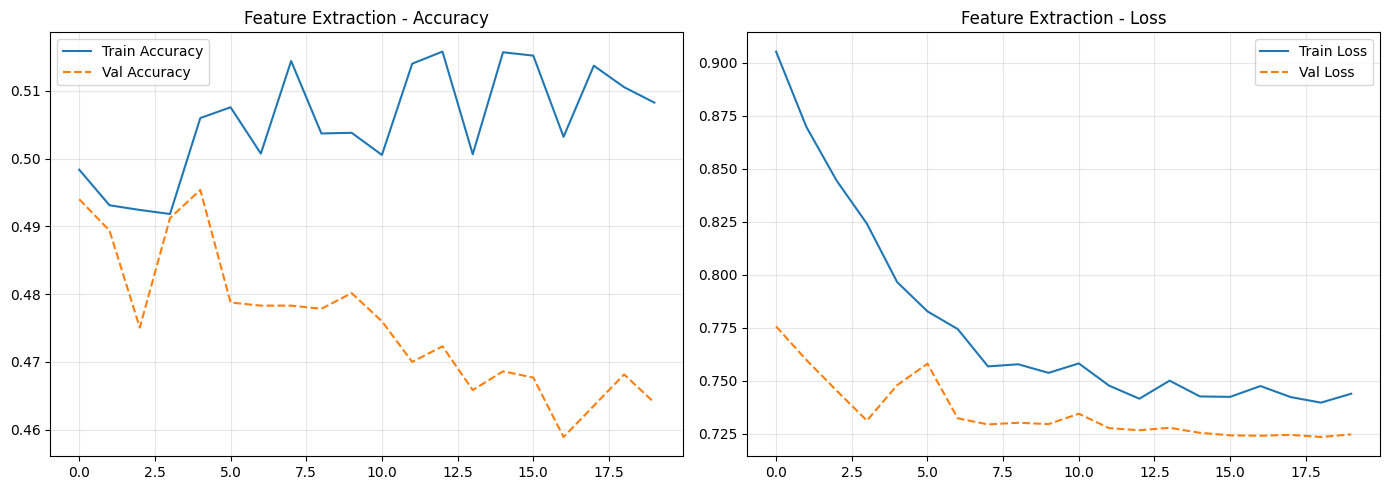


Feature Extraction (val)
      loss: 0.7234
  accuracy: 0.4681
 precision: 0.4706
    recall: 0.5097
        f1: 0.4894
       auc: 0.4491

              precision    recall  f1-score   support

    formalin     0.4653    0.4266    0.4451      1083
       fresh     0.4706    0.5097    0.4894      1083

    accuracy                         0.4681      2166
   macro avg     0.4679    0.4681    0.4672      2166
weighted avg     0.4679    0.4681    0.4672      2166



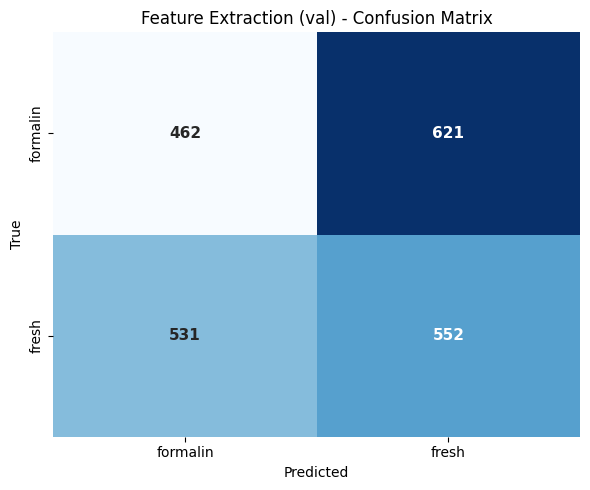

In [ ]:
plot_learning_curves(tl_history, 'Feature Extraction')
fe_val_metrics = evaluate_model(tl_model, val_dataset, class_names, 'Feature Extraction (val)')


## Fine-tune

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

FINETUNE_LR = LR / 10

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')],
)

ft_history = tl_model.fit(
    train_dataset, validation_data=val_dataset, epochs=10,
    callbacks=make_callbacks('finetuned'), verbose=1,
)


Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4939 - auc: 0.4917 - loss: 0.8120 - precision: 0.4816 - recall: 0.4947
Epoch 1: val_loss improved from None to 0.75123, saving model to /content/models/finetuned_best.keras

Epoch 1: finished saving model to /content/models/finetuned_best.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - accuracy: 0.4896 - auc: 0.4877 - loss: 0.8077 - precision: 0.4893 - recall: 0.4875 - val_accuracy: 0.4940 - val_auc: 0.4819 - val_loss: 0.7512 - val_precision: 0.4805 - val_recall: 0.1477 - learning_rate: 1.0000e-05
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5043 - auc: 0.5048 - loss: 0.7882 - precision: 0.4910 - recall: 0.4981
Epoch 2: val_loss improved from 0.75123 to 0.74855, saving model to /content/models/finetuned_best.keras

Epoch 2: finished saving model to /content/models/finetuned_best.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 33s 103ms/step - accuracy: 0.5039 - auc: 0.5009 - loss: 0.7913 - precision: 0.5037

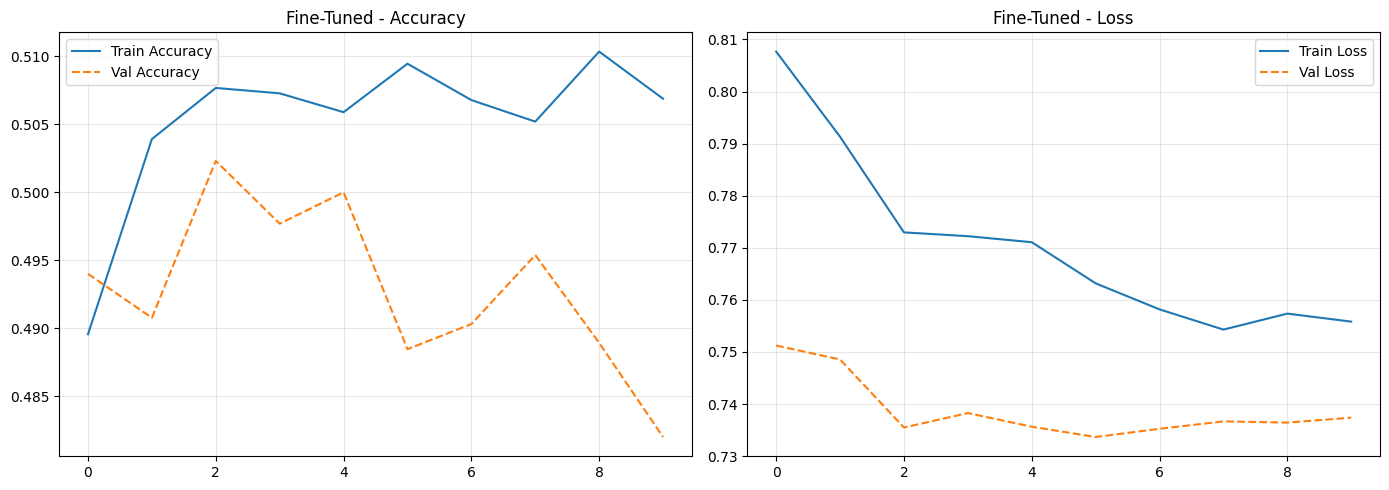


Fine-Tuned (val)
      loss: 0.7337
  accuracy: 0.4885
 precision: 0.4876
    recall: 0.4552
        f1: 0.4709
       auc: 0.4930

              precision    recall  f1-score   support

    formalin     0.4892    0.5217    0.5049      1083
       fresh     0.4876    0.4552    0.4709      1083

    accuracy                         0.4885      2166
   macro avg     0.4884    0.4885    0.4879      2166
weighted avg     0.4884    0.4885    0.4879      2166



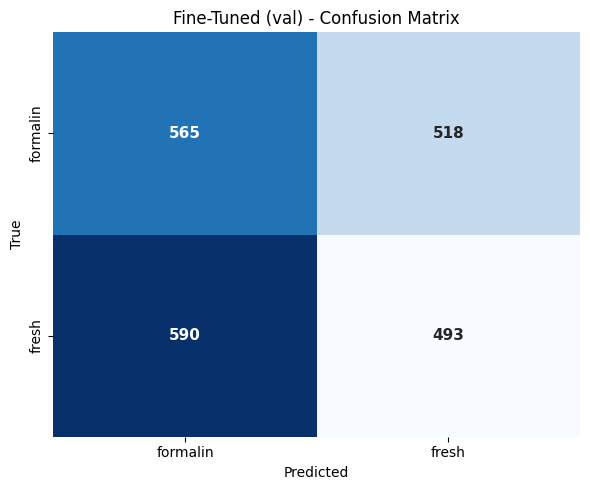

In [ ]:
plot_learning_curves(ft_history, 'Fine-Tuned')
ft_val_metrics = evaluate_model(tl_model, val_dataset, class_names, 'Fine-Tuned (val)')


## Select best model

In [ ]:
fe_model = tf.keras.models.load_model('/content/models/feature_extraction_best.keras')
ft_model = tf.keras.models.load_model('/content/models/finetuned_best.keras')

fe_metrics = evaluate_model(fe_model, val_dataset, class_names, 'Feature Extraction checkpoint (val)', plot=False)
ft_metrics = evaluate_model(ft_model, val_dataset, class_names, 'Fine-Tuned checkpoint (val)', plot=False)

comparison = pd.DataFrame([fe_metrics, ft_metrics], index=['feature_extraction', 'fine_tuned'])
print(comparison)

if ft_metrics['loss'] <= fe_metrics['loss']:
    final_model = ft_model
    final_name = 'fine_tuned'
else:
    final_model = fe_model
    final_name = 'feature_extraction'

print(f'Selected: {final_name}')



Feature Extraction checkpoint (val)
      loss: 0.7234
  accuracy: 0.4681
 precision: 0.4706
    recall: 0.5097
        f1: 0.4894
       auc: 0.4491

              precision    recall  f1-score   support

    formalin     0.4653    0.4266    0.4451      1083
       fresh     0.4706    0.5097    0.4894      1083

    accuracy                         0.4681      2166
   macro avg     0.4679    0.4681    0.4672      2166
weighted avg     0.4679    0.4681    0.4672      2166


Fine-Tuned checkpoint (val)
      loss: 0.7337
  accuracy: 0.4885
 precision: 0.4876
    recall: 0.4552
        f1: 0.4709
       auc: 0.4930

              precision    recall  f1-score   support

    formalin     0.4892    0.5217    0.5049      1083
       fresh     0.4876    0.4552    0.4709      1083

    accuracy                         0.4885      2166
   macro avg     0.4884    0.4885    0.4879      2166
weighted avg     0.4884    0.4885    0.4879      2166

                        loss  accuracy  precision 

## Test set evaluation


feature_extraction (test)
      loss: 0.7220
  accuracy: 0.4705
 precision: 0.4728
    recall: 0.5120
        f1: 0.4916
       auc: 0.4458

              precision    recall  f1-score   support

    formalin     0.4679    0.4291    0.4476      1086
       fresh     0.4728    0.5120    0.4916      1086

    accuracy                         0.4705      2172
   macro avg     0.4703    0.4705    0.4696      2172
weighted avg     0.4703    0.4705    0.4696      2172



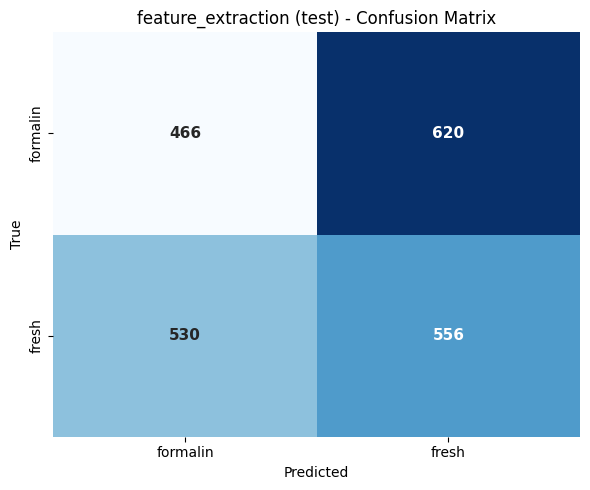

In [ ]:
test_metrics = evaluate_model(final_model, test_dataset, class_names, f'{final_name} (test)')


## Predict on a single image

In [ ]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = np.expand_dims(tf.keras.utils.img_to_array(img), axis=0)

    plt.figure(figsize=(3, 3))
    plt.imshow(img); plt.axis('off'); plt.show()
    plt.close()

    prob = model.predict(img_array, verbose=0)[0][0]
    label = class_names[int(prob >= 0.5)]
    confidence = prob if prob >= 0.5 else 1 - prob
    print(f'{label} ({confidence:.4f})')

# predict_image('/content/your-test-image.jpg', final_model, class_names)


## Save model

In [ ]:
FINAL_MODEL_PATH = '/content/model.keras'
final_model.save(FINAL_MODEL_PATH)
print(FINAL_MODEL_PATH, test_metrics)


/content/model.keras {'loss': 0.7219899892807007, 'accuracy': 0.4705340564250946, 'precision': 0.47278910875320435, 'recall': 0.5119705200195312, 'f1': 0.4916003536693192, 'auc': 0.4457891881465912}
